# US Flight Delays Network Analysis
## Step 4: Feature Engineering & Predictive Modeling

**Course:** CS-GY 6513-C Big Data — Spring 2026

**Team:** Mirsaid Abbasov [ma9197], Nicholas Pesa [np2354], Ferdi Fadillah [ff2364]

---

This step addresses **Objective 4** of the proposal — training a binary classifier to predict whether a flight will be delayed by ≥15 minutes at arrival (`ARR_DEL15`).

### Pipeline
1. Load cleaned flight data (Step 1) and enriched airport nodes with centrality (Step 3)
2. Engineer features combining operational + network information
3. Time-based train/test split (2019–2022 train, 2023 test)
4. Train **Logistic Regression** and **Random Forest** with Spark MLlib
5. Evaluate both models (AUC, precision, recall, F1, confusion matrix)
6. Inspect Random Forest feature importance
7. Save the better model

### Feature Groups
**Operational features** (known before the flight):
- `OP_UNIQUE_CARRIER` — airline
- `MONTH`, `DAY_OF_WEEK` — seasonality and weekly patterns
- `hour_bucket` — derived from `CRS_DEP_TIME` (scheduled departure)
- `DISTANCE` — flight distance

**Network features** (from Step 3 graph analysis):
- Origin-side: PageRank (traffic & delay), betweenness, historical delay rate, delay propagation score
- Destination-side: same metrics

### Caveats (important)
1. **We do not use `DEP_DELAY` or cause-specific delay fields** (CARRIER_DELAY, WEATHER_DELAY, etc.) as features — these are only known *after* the flight departs, so including them would be target leakage. Predicting arrival delay from departure delay is trivial and uninteresting.
2. **Mild network-feature leakage:** Step 3's centrality metrics were computed over 2019–2023 globally. For pure rigor we would recompute network features on the training window only. For this project, global network structure changes slowly year-to-year, so we accept this as a minor approximation and flag it transparently.
3. **Sampling:** We use a 10% stratified sample for training to stay within Colab memory. The sample preserves class balance and is more than sufficient (~3M rows) for stable model estimates.

## 1. Environment Setup

In [1]:
!pip install pyspark -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder \
    .appName("FlightDelays_Step4") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "100") \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Spark version: 4.0.2


## 2. Load Data

In [4]:
FLIGHTS_PATH = "/content/drive/MyDrive/Big Data Project/parquet/completed_flights"
NODES_PATH   = "/content/drive/MyDrive/Big Data Project/parquet/nodes_enriched_centrality"

flights = spark.read.parquet(FLIGHTS_PATH)
nodes   = spark.read.parquet(NODES_PATH)

print(f"Flights: {flights.count():,}")
print(f"Nodes:   {nodes.count()}")

Flights: 30,821,441
Nodes:   381


## 3. Feature Engineering

### 3.1 Derive `hour_bucket` from scheduled departure time
`CRS_DEP_TIME` is stored as HHMM integer (e.g. 1435 = 2:35 PM). We extract the hour and bucket it.

In [5]:
flights = flights.withColumn(
    'dep_hour',
    (F.col('CRS_DEP_TIME') / 100).cast('int')
)

# Bucket: 0=night (0-5), 1=morning (6-11), 2=afternoon (12-16), 3=evening (17-20), 4=late (21-23)
flights = flights.withColumn(
    'hour_bucket',
    F.when(F.col('dep_hour') < 6, 0)
     .when(F.col('dep_hour') < 12, 1)
     .when(F.col('dep_hour') < 17, 2)
     .when(F.col('dep_hour') < 21, 3)
     .otherwise(4)
)

flights.groupBy('hour_bucket').count().orderBy('hour_bucket').show()

+-----------+--------+
|hour_bucket|   count|
+-----------+--------+
|          0|  770291|
|          1|12153703|
|          2| 9189241|
|          3| 6803476|
|          4| 1904730|
+-----------+--------+



### 3.2 Prepare network features for joining
We select the network metrics we want to use and prepare two versions (origin-side, destination-side).

In [6]:
net_feats = nodes.select(
    'iata',
    'pagerank_traffic',
    'pagerank_delay',
    'betweenness',
    'out_pct_delayed_15',
    'in_pct_delayed_15',
    'delay_propagation_score',
    'out_degree',
    'in_degree'
)

# Origin-side (rename columns with origin_ prefix)
origin_feats = net_feats.select(
    F.col('iata').alias('ORIGIN'),
    *[F.col(c).alias(f'origin_{c}') for c in net_feats.columns if c != 'iata']
)

# Destination-side
dest_feats = net_feats.select(
    F.col('iata').alias('DEST'),
    *[F.col(c).alias(f'dest_{c}') for c in net_feats.columns if c != 'iata']
)

origin_feats.show(3)
dest_feats.show(3)

+------+-----------------------+---------------------+------------------+-------------------------+------------------------+------------------------------+-----------------+----------------+
|ORIGIN|origin_pagerank_traffic|origin_pagerank_delay|origin_betweenness|origin_out_pct_delayed_15|origin_in_pct_delayed_15|origin_delay_propagation_score|origin_out_degree|origin_in_degree|
+------+-----------------------+---------------------+------------------+-------------------------+------------------------+------------------------------+-----------------+----------------+
|   BGM|   4.621401846908029E-4| 4.500005599901772...|               0.0|      0.13954344624447718|     0.15185185185185185|          6.279462895297393E-5|                2|               2|
|   DLG|   5.165818753854254E-4| 5.161780645369375E-4|               0.0|      0.24277456647398843|     0.15741507870753935|          1.253149058413374...|                2|               2|
|   INL|   4.982807132558824E-4| 4.7307651236

### 3.3 Join network features onto flight records

In [7]:
flights_feat = flights \
    .join(F.broadcast(origin_feats), on='ORIGIN', how='left') \
    .join(F.broadcast(dest_feats),   on='DEST',   how='left')

print(f"Records after join: {flights_feat.count():,}")

Records after join: 30,821,441


In [8]:
# Drop any rows with missing network features (unmatched small airports)
before = flights_feat.count()
flights_feat = flights_feat.dropna(subset=[
    'origin_pagerank_traffic', 'dest_pagerank_traffic'
])
after = flights_feat.count()
print(f"Dropped {before - after:,} rows with missing network features")
print(f"Final records: {after:,}")

Dropped 0 rows with missing network features
Final records: 30,821,441


### 3.4 Final feature selection

In [9]:
categorical_cols = ['OP_UNIQUE_CARRIER', 'MONTH', 'DAY_OF_WEEK', 'hour_bucket']

numeric_cols = [
    'DISTANCE',
    'origin_pagerank_traffic', 'origin_pagerank_delay', 'origin_betweenness',
    'origin_out_pct_delayed_15', 'origin_delay_propagation_score',
    'origin_out_degree', 'origin_in_degree',
    'dest_pagerank_traffic', 'dest_pagerank_delay', 'dest_betweenness',
    'dest_in_pct_delayed_15', 'dest_delay_propagation_score',
]

target_col = 'ARR_DEL15'

# Keep only what we need (plus YEAR for the time split)
keep_cols = ['YEAR'] + categorical_cols + numeric_cols + [target_col]
model_df = flights_feat.select(*keep_cols)

# Make sure target is int
model_df = model_df.withColumn(target_col, F.col(target_col).cast('int'))

print("Feature summary:")
print(f"  Categorical: {categorical_cols}")
print(f"  Numeric:     {numeric_cols}")
print(f"  Target:      {target_col}")

# Class balance
model_df.groupBy(target_col).count().show()

Feature summary:
  Categorical: ['OP_UNIQUE_CARRIER', 'MONTH', 'DAY_OF_WEEK', 'hour_bucket']
  Numeric:     ['DISTANCE', 'origin_pagerank_traffic', 'origin_pagerank_delay', 'origin_betweenness', 'origin_out_pct_delayed_15', 'origin_delay_propagation_score', 'origin_out_degree', 'origin_in_degree', 'dest_pagerank_traffic', 'dest_pagerank_delay', 'dest_betweenness', 'dest_in_pct_delayed_15', 'dest_delay_propagation_score']
  Target:      ARR_DEL15
+---------+--------+
|ARR_DEL15|   count|
+---------+--------+
|        1| 5595003|
|        0|25226438|
+---------+--------+



## 4. Train/Test Split (Time-Based) + Sampling

- **Train:** 2019–2022 flights (4 years)
- **Test:** 2023 flights (held out for honest evaluation)
- We stratified-sample 10% of the training set for tractable runtime on Colab.
- We sample 20% of test set for quicker evaluation (still hundreds of thousands of rows).

In [10]:
TRAIN_SAMPLE_FRAC = 0.10   # bump up if you have more RAM/time
TEST_SAMPLE_FRAC  = 0.20

train_full = model_df.filter(F.col('YEAR') <= 2022)
test_full  = model_df.filter(F.col('YEAR') == 2023)

# Stratified sample to preserve class balance
train_df = train_full.sampleBy(target_col, fractions={0: TRAIN_SAMPLE_FRAC, 1: TRAIN_SAMPLE_FRAC}, seed=42)
test_df  = test_full.sampleBy(target_col,  fractions={0: TEST_SAMPLE_FRAC,  1: TEST_SAMPLE_FRAC},  seed=42)

train_df = train_df.drop('YEAR')
test_df  = test_df.drop('YEAR')

# Cache since we'll reuse
train_df.cache()
test_df.cache()

print(f"Train size: {train_df.count():,}")
print(f"Test size:  {test_df.count():,}")

print("\nTrain class balance:")
train_df.groupBy(target_col).count().show()
print("Test class balance:")
test_df.groupBy(target_col).count().show()

Train size: 2,408,563
Test size:  1,350,611

Train class balance:
+---------+-------+
|ARR_DEL15|  count|
+---------+-------+
|        1| 420839|
|        0|1987724|
+---------+-------+

Test class balance:
+---------+-------+
|ARR_DEL15|  count|
+---------+-------+
|        1| 278273|
|        0|1072338|
+---------+-------+



## 5. Preprocessing Pipeline (Shared)

- `StringIndexer` for each categorical
- `OneHotEncoder` for LR (RF would also accept one-hot; keeping one pipeline keeps things simple)
- `VectorAssembler` to produce the final `features` column

In [11]:
# Indexers
indexers = [
    StringIndexer(inputCol=c, outputCol=f'{c}_idx', handleInvalid='keep')
    for c in categorical_cols
]

# One-hot encoders
encoders = [
    OneHotEncoder(inputCol=f'{c}_idx', outputCol=f'{c}_ohe')
    for c in categorical_cols
]

ohe_cols = [f'{c}_ohe' for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=ohe_cols + numeric_cols,
    outputCol='features',
    handleInvalid='skip'
)

preprocess_stages = indexers + encoders + [assembler]
print(f"Preprocessing stages: {len(preprocess_stages)}")

Preprocessing stages: 9


## 6. Model 1 — Logistic Regression

In [12]:
lr = LogisticRegression(
    featuresCol='features',
    labelCol=target_col,
    maxIter=30,
    regParam=0.01,
    elasticNetParam=0.0
)

lr_pipeline = Pipeline(stages=preprocess_stages + [lr])

print("Training Logistic Regression... (several minutes)")
lr_model = lr_pipeline.fit(train_df)
print("Done.")

Training Logistic Regression... (several minutes)
Done.


In [13]:
lr_preds = lr_model.transform(test_df)
lr_preds.select(target_col, 'prediction', 'probability').show(5, truncate=False)

+---------+----------+----------------------------------------+
|ARR_DEL15|prediction|probability                             |
+---------+----------+----------------------------------------+
|0        |0.0       |[0.8191151191196864,0.18088488088031363]|
|0        |0.0       |[0.8565104061712993,0.14348959382870075]|
|0        |0.0       |[0.9178019428744425,0.0821980571255575] |
|0        |0.0       |[0.9104928089531401,0.08950719104685989]|
|0        |0.0       |[0.8608987394344857,0.1391012605655143] |
+---------+----------+----------------------------------------+
only showing top 5 rows


## 7. Model 2 — Random Forest

In [14]:
rf = RandomForestClassifier(
    featuresCol='features',
    labelCol=target_col,
    numTrees=50,
    maxDepth=10,
    seed=42
)

rf_pipeline = Pipeline(stages=preprocess_stages + [rf])

print("Training Random Forest... (several minutes)")
rf_model = rf_pipeline.fit(train_df)
print("Done.")

Training Random Forest... (several minutes)
Done.


In [15]:
rf_preds = rf_model.transform(test_df)
rf_preds.select(target_col, 'prediction', 'probability').show(5, truncate=False)

+---------+----------+----------------------------------------+
|ARR_DEL15|prediction|probability                             |
+---------+----------+----------------------------------------+
|0        |0.0       |[0.819508035290756,0.180491964709244]   |
|0        |0.0       |[0.8453544152783568,0.1546455847216433] |
|0        |0.0       |[0.8826253550769644,0.11737464492303556]|
|0        |0.0       |[0.8826253550769644,0.11737464492303556]|
|0        |0.0       |[0.844151220763548,0.15584877923645207] |
+---------+----------+----------------------------------------+
only showing top 5 rows


## 8. Evaluation

In [16]:
def evaluate(preds, label_col, model_name):
    """Compute AUC, accuracy, precision, recall, F1, and confusion matrix."""
    auc_eval = BinaryClassificationEvaluator(labelCol=label_col, metricName='areaUnderROC')
    auc = auc_eval.evaluate(preds)

    mc_eval = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol='prediction')
    acc = mc_eval.setMetricName('accuracy').evaluate(preds)
    f1  = mc_eval.setMetricName('f1').evaluate(preds)
    # Precision/recall for the positive class (delayed = 1)
    prec_1 = mc_eval.setMetricName('precisionByLabel').setMetricLabel(1.0).evaluate(preds)
    rec_1  = mc_eval.setMetricName('recallByLabel').setMetricLabel(1.0).evaluate(preds)

    # Confusion matrix
    cm = preds.groupBy(label_col, 'prediction').count().orderBy(label_col, 'prediction').toPandas()

    print(f"\n===== {model_name} =====")
    print(f"AUC:                   {auc:.4f}")
    print(f"Accuracy:              {acc:.4f}")
    print(f"F1 (weighted):         {f1:.4f}")
    print(f"Precision (delayed=1): {prec_1:.4f}")
    print(f"Recall (delayed=1):    {rec_1:.4f}")
    print(f"\nConfusion matrix (rows=actual, cols=predicted):")
    print(cm.pivot(index=label_col, columns='prediction', values='count').fillna(0).astype(int))

    return {
        'model': model_name, 'auc': auc, 'accuracy': acc, 'f1': f1,
        'precision_pos': prec_1, 'recall_pos': rec_1
    }

lr_metrics = evaluate(lr_preds, target_col, 'Logistic Regression')
rf_metrics = evaluate(rf_preds, target_col, 'Random Forest')


===== Logistic Regression =====
AUC:                   0.6401
Accuracy:              0.7939
F1 (weighted):         0.7029
Precision (delayed=1): 0.4559
Recall (delayed=1):    0.0004

Confusion matrix (rows=actual, cols=predicted):
prediction      0.0  1.0
ARR_DEL15               
0           1072196  142
1            278154  119

===== Random Forest =====
AUC:                   0.6363
Accuracy:              0.7940
F1 (weighted):         0.7028
Precision (delayed=1): 0.0000
Recall (delayed=1):    0.0000

Confusion matrix (rows=actual, cols=predicted):
prediction      0.0
ARR_DEL15          
0           1072338
1            278273


In [17]:
# Side-by-side comparison
comparison = pd.DataFrame([lr_metrics, rf_metrics])
print("\n===== MODEL COMPARISON =====")
print(comparison.to_string(index=False))


===== MODEL COMPARISON =====
              model      auc  accuracy       f1  precision_pos  recall_pos
Logistic Regression 0.640129  0.793948 0.702938       0.455939    0.000428
      Random Forest 0.636321  0.793965 0.702779       0.000000    0.000000


## 9. Feature Importance (Random Forest)

In [18]:
# The RF model is the last stage in rf_pipeline
rf_stage = rf_model.stages[-1]
importances = rf_stage.featureImportances.toArray()

# Reconstruct feature names — one-hot expanded categoricals + numeric
def get_feature_names(fitted_pipeline, categorical_cols, numeric_cols):
    names = []
    stages = fitted_pipeline.stages
    # Indexer stages hold label lists we can use to enumerate one-hot slots
    for i, cat in enumerate(categorical_cols):
        indexer_model = stages[i]  # first N stages are indexers
        labels = indexer_model.labels  # excludes unseen 'keep' level
        # OneHotEncoder in Spark drops the last category by default
        for lbl in labels[:-1]:
            names.append(f'{cat}={lbl}')
    names += numeric_cols
    return names

feat_names = get_feature_names(rf_model, categorical_cols, numeric_cols)

# Align length (in case of slight off-by-one with OHE handleInvalid)
min_len = min(len(feat_names), len(importances))
fi_df = pd.DataFrame({
    'feature':    feat_names[:min_len],
    'importance': importances[:min_len]
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 features by importance:")
print(fi_df.head(20).to_string(index=False))

Top 20 features by importance:
                     feature  importance
               hour_bucket=4    0.295313
     origin_pagerank_traffic    0.144074
       dest_pagerank_traffic    0.089799
                     MONTH=2    0.035748
        OP_UNIQUE_CARRIER=B6    0.032884
                    DISTANCE    0.030549
       origin_pagerank_delay    0.029222
        OP_UNIQUE_CARRIER=DL    0.028618
   origin_out_pct_delayed_15    0.023112
          origin_betweenness    0.019954
                    MONTH=10    0.015623
           origin_out_degree    0.015126
            origin_in_degree    0.014070
                    MONTH=11    0.013763
        OP_UNIQUE_CARRIER=WN    0.013046
         dest_pagerank_delay    0.011986
dest_delay_propagation_score    0.011145
            dest_betweenness    0.009674
                     MONTH=6    0.008165
      dest_in_pct_delayed_15    0.007826


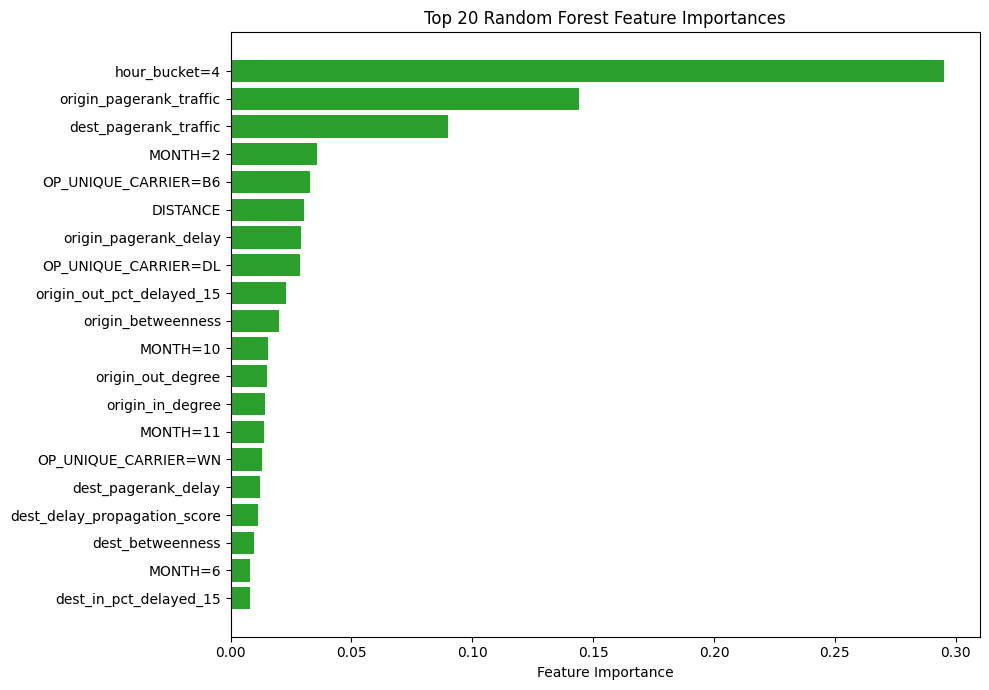

In [19]:
# Plot top 20
top_fi = fi_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_fi['feature'], top_fi['importance'], color='#2ca02c')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Random Forest Feature Importances')
plt.tight_layout()
plt.show()

## 10. Save Models

We save both models so they can be reloaded for inference later.

In [20]:
LR_MODEL_PATH = "/content/drive/MyDrive/Big Data Project/models/lr_model"
RF_MODEL_PATH = "/content/drive/MyDrive/Big Data Project/models/rf_model"

lr_model.write().overwrite().save(LR_MODEL_PATH)
rf_model.write().overwrite().save(RF_MODEL_PATH)

print(f"Saved LR model to: {LR_MODEL_PATH}")
print(f"Saved RF model to: {RF_MODEL_PATH}")

Saved LR model to: /content/drive/MyDrive/Big Data Project/models/lr_model
Saved RF model to: /content/drive/MyDrive/Big Data Project/models/rf_model


In [21]:
# Also save predictions and feature importance to Parquet/CSV
FI_PATH = "/content/drive/MyDrive/Big Data Project/results/rf_feature_importance.csv"

import os
os.makedirs("/content/drive/MyDrive/Big Data Project/results", exist_ok=True)
fi_df.to_csv(FI_PATH, index=False)
print(f"Saved feature importance to: {FI_PATH}")

Saved feature importance to: /content/drive/MyDrive/Big Data Project/results/rf_feature_importance.csv


## Summary

**What we did:**
- Engineered a feature set combining operational signals (carrier, time, distance) with graph-based network features from Step 3
- Performed a time-based train/test split (train 2019–2022, test 2023) to simulate honest forward-in-time prediction
- Trained and evaluated **Logistic Regression** and **Random Forest** in Spark MLlib
- Reported AUC, accuracy, F1, precision, recall on the held-out 2023 test set
- Extracted Random Forest feature importances to identify the strongest predictors

**What to look for in the results:**
- **AUC above ~0.60** is reasonable for delay prediction without same-flight leakage (departure delay excluded on purpose).
- If network features like `origin_delay_propagation_score` or `origin_pagerank_delay` rank high in importance, it confirms that **graph structure genuinely adds predictive power** beyond simple operational features — which is the main hypothesis of this project.

**Next step (Step 5 — final):** Final analysis notebook + write-up: putting together the airport rankings, fragile routes, model results, and network visualizations into a clean final report deliverable.

In [22]:
spark.stop()
print("Spark session stopped. Step 4 complete!")

Spark session stopped. Step 4 complete!
